# Deep Learning — Projeto Final
> Previsão de cancelamento de reservas hoteleiras com redes neuronais

**Curso:** Pós-graduação em Data Science e Business Intelligence  
**Disciplina:** Deep Learning | **Aluno:** Ricardo Filipe Fernandes da Silva


## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

from src.config        import TARGET, CATEGORICAL_COLS, NUMERIC_COLS, DEFAULT_DATA_PATH
from src.data          import load_data, reconstruct_booking_date
from src.preprocessing import clean_data, split_data, prepare_splits
from src.eda           import (dataset_overview, plot_missing, plot_target,
                               analyze_duplicates, plot_target_correlation)
from src.models        import (build_fnn_baseline,build_fnn_dense64_32,
                               build_fnn_final,build_cnn_baseline,
                               build_cnn_final,)
from src.train         import train_model, train_model_no_early_stop
from src.evaluate      import (evaluate_model, plot_history,
                               plot_confusion_matrix, compare_models, reshape_for_cnn)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.21.0


## 2. Problema e Objetivo

**Problema:** prever, no momento da reserva, se uma reserva hoteleira será cancelada.  
**Tipo:** classificação binária com dados tabulares.  
**Target:** `is_canceled` (0 = não cancelado · 1 = cancelado)  
**Métrica:** `accuracy` como métrica principal, complementada na avaliação final por métricas por classe (`precision`, `recall` e `F1-score`).

Serão comparadas duas abordagens:
- **FNN** (dense layers) — baseline, mais natural para dados tabulares
- **CNN** (Conv1D) — para avaliar se convolution layers acrescentam valor preditivo em dados tabulares


## 3. Dataset e EDA


In [2]:
df = load_data(DEFAULT_DATA_PATH)
dataset_overview(df)


Dataset carregado: 119,390 observações, 32 colunas.
Shape: (119390, 32)

Missing values:
children         4
country        488
agent        16340
company     112593
dtype: int64

Duplicados exatos: 31,994

Distribuição da target (is_canceled):
is_canceled
0    0.63
1    0.37
Name: proportion, dtype: float64


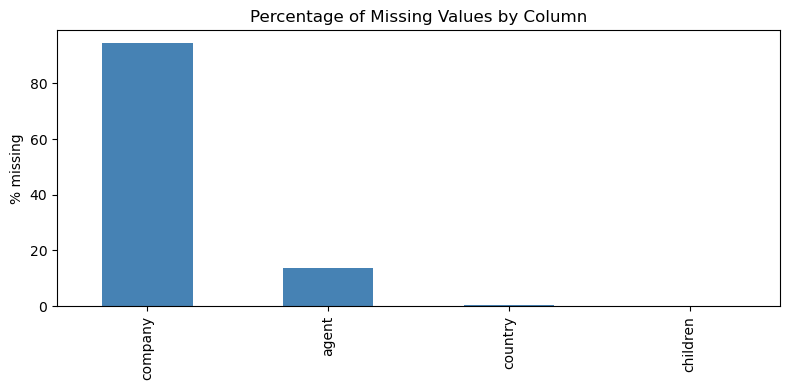

Distribuição (contagem):
 is_canceled
0    75166
1    44224
Name: count, dtype: int64

Distribuição (%):
 is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64


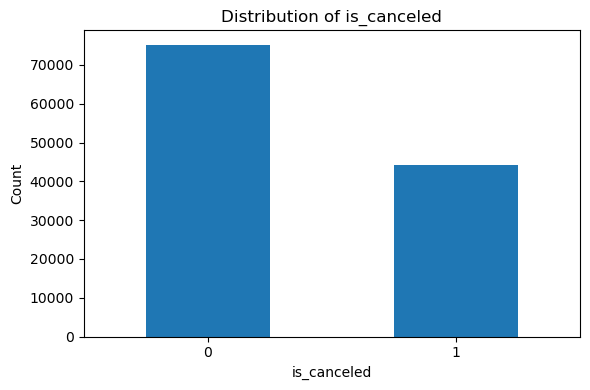

In [3]:
plot_missing(df)
plot_target(df)


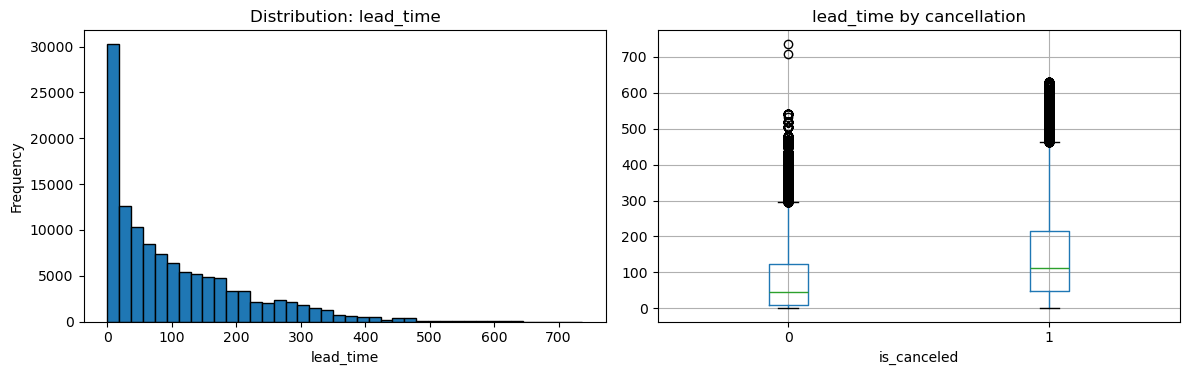

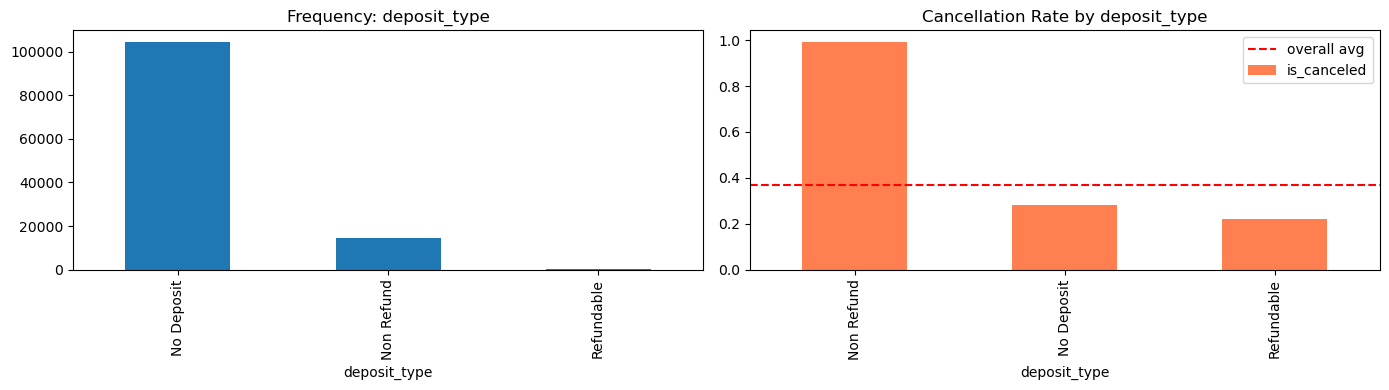

In [4]:
# lead_time — feature numérica mais discriminativa
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["lead_time"].dropna(), bins=40, edgecolor="black")
axes[0].set_title("Distribution: lead_time")
axes[0].set_xlabel("lead_time")
axes[0].set_ylabel("Frequency")
df.boxplot(column="lead_time", by="is_canceled", ax=axes[1])
axes[1].set_title("lead_time by cancellation")
axes[1].set_xlabel("is_canceled")
plt.suptitle("")
plt.tight_layout()
plt.show()

# deposit_type — variável categórica com maior taxa de cancelamento diferenciada
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df["deposit_type"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Frequency: deposit_type")
(df.groupby("deposit_type")["is_canceled"].mean()
   .sort_values(ascending=False)
   .plot(kind="bar", ax=axes[1], color="coral"))
axes[1].set_title("Cancellation Rate by deposit_type")
axes[1].axhline(df["is_canceled"].mean(), color="red", linestyle="--", label="overall avg")
axes[1].legend()
plt.tight_layout()
plt.show()


In [5]:
analyze_duplicates(df)


Duplicados exatos : 31,994  (26.8%)

Distribuição target — com duplicados:
is_canceled
0    0.6296
1    0.3704
Name: proportion, dtype: float64

Distribuição target — sem duplicados:
is_canceled
0    0.7251
1    0.2749
Name: proportion, dtype: float64


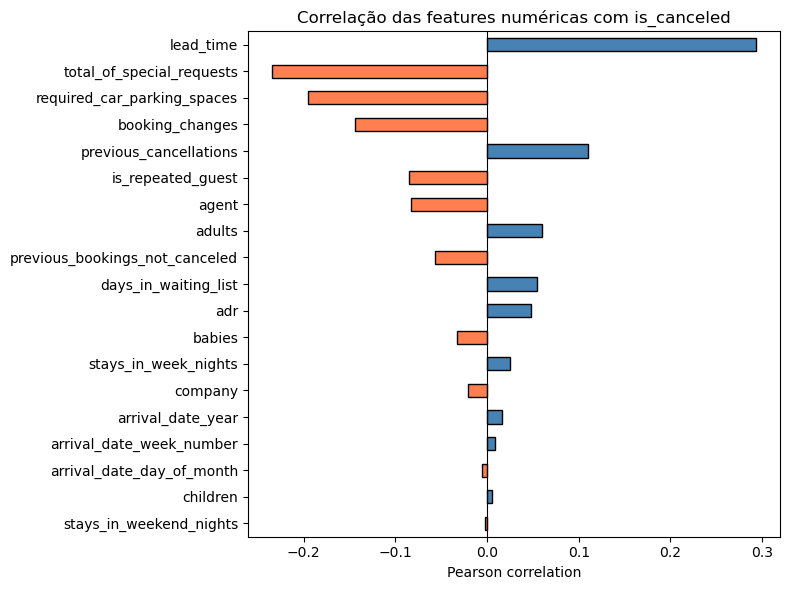

lead_time                      0.293123
total_of_special_requests     -0.234658
required_car_parking_spaces   -0.195498
booking_changes               -0.144381
previous_cancellations         0.110133
Name: is_canceled, dtype: float64


In [6]:
corr = plot_target_correlation(df)
print(corr.head(5))  # top 5 features mais correlacionadas com a target


**Principais insights:**

| Variável | Relevância |
|---|---|
| `lead_time` | Feature numérica mais correlacionada com a target — reservas com maior antecedência cancelam mais |
| `deposit_type` | *Non Refund* com taxa de cancelamento muito acima da média |
| `market_segment` | Segmento *Groups* com risco superior |
| `company` | 94% missing — será removida |
| Duplicados | ~32k registos mantidos — remoção alteraria distribuição da target de 37% para 27% |
| Target | ~63% não cancelado / ~37% cancelado — sem desequilíbrio extremo |


## 4. Preparação dos Dados

- **Duplicados mantidos** — sem identificador único de reserva não é possível confirmar redundância; a remoção alteraria a distribuição da target de 37% para 27%.
- **Leakage removido** — `reservation_status`, `reservation_status_date`, `booking_changes`, `days_in_waiting_list`, `assigned_room_type`.
- **Split temporal** — divisão cronológica via `booking_date = arrival_date − lead_time`: treino até Jun 2016, validação Jul–Dez 2016, teste a partir de 2017.
- **Preprocessing** — `StandardScaler` (numéricas) + `OneHotEncoder` (categóricas), fit exclusivo no treino.


In [7]:
df_dated = reconstruct_booking_date(df)
df_clean = clean_data(df_dated)

train_df, val_df, test_df = split_data(df_clean)

X_train_p, X_val_p, X_test_p, y_train, y_val, y_test, preprocessor = prepare_splits(
    train_df, val_df, test_df
)

X_train_cnn = reshape_for_cnn(X_train_p)
X_val_cnn   = reshape_for_cnn(X_val_p)
X_test_cnn  = reshape_for_cnn(X_test_p)

INPUT_DIM     = X_train_p.shape[1]
INPUT_DIM_CNN = X_train_cnn.shape[1]


Dataset após limpeza: 119,390 observações, 29 colunas.
Missing values restantes: 0
  Train       : 66,253 obs (55.5%)  |  cancel rate: 39.0%  |  2013-06-24 → 2016-06-30
  Validation  : 26,572 obs (22.3%)  |  cancel rate: 37.7%  |  2016-07-01 → 2016-12-31
  Test        : 26,565 obs (22.3%)  |  cancel rate: 31.6%  |  2017-01-01 → 2017-08-31
X_train: (66253, 455)  |  X_val: (26572, 455)  |  X_test: (26565, 455)


## 5. FNN Baseline

Arquitectura mínima — `Dense(1, sigmoid)` — equivalente a uma regressão logística em Keras.  
Serve como referência: qualquer modelo mais complexo tem de superar estes valores para justificar a complexidade adicional.


Model: "fnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │           456 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 456 (1.78 KB)

 Trainable params: 456 (1.78 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8192 - loss: 0.4215 - val_accuracy: 0.7700 - val_loss: 0.4644
Epoch 2/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8459 - loss: 0.3377 - val_accuracy: 0.7726 - val_loss: 0.4565
Epoch 3/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8496 - loss: 0.3241 - val_accuracy: 0.7718 - val_loss: 0.4552
Epoch 4/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8518 - loss: 0.3186 - val_accuracy: 0.7753 - val_loss: 0.4536
Epoch 5/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8534 - loss: 0.3157 - val_accuracy: 0.7738 - val_loss: 0.4551
Epoch 6/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8559 - loss: 0.3139 - val_accuracy: 0.7760 - val_loss: 0.4508
Epoch 7/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8570 - loss: 0.3127 - val_accuracy: 0.7765 - val_loss: 0.4520
Epoch 8/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8580 - loss: 0.3119 - 

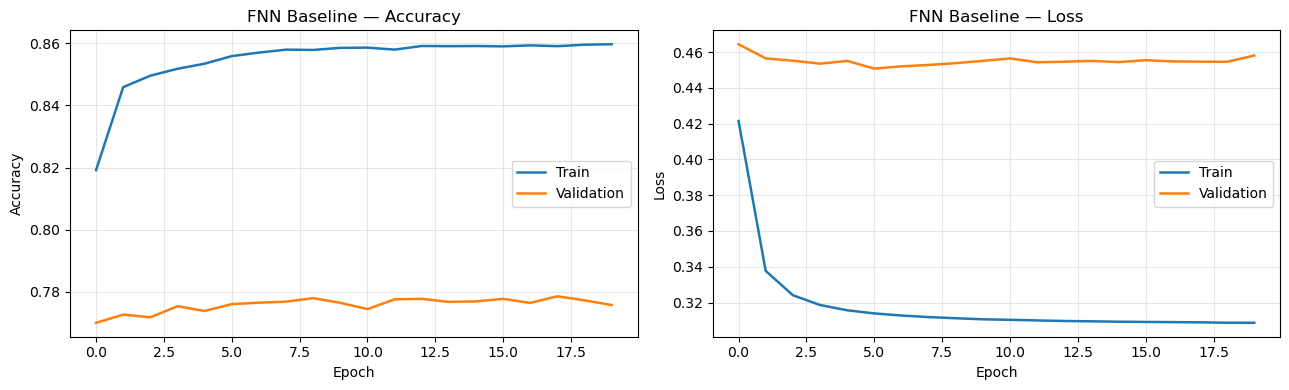

In [8]:
fnn_baseline = build_fnn_baseline(INPUT_DIM)
fnn_baseline.summary()

history_fnn_baseline = train_model_no_early_stop(
    fnn_baseline, X_train_p, y_train, X_val_p, y_val, epochs=20, batch_size=32
)
fnn_baseline_results = evaluate_model(
    fnn_baseline, X_train_p, y_train, X_val_p, y_val, X_test_p, y_test
)
plot_history(history_fnn_baseline, "FNN Baseline")


O baseline atinge ~86% no treino e ~77% em validação e teste — referência estabelecida.  
Numa fase experimental foram testadas arquiteturas mais profundas sem regularização (Dense(64)+Dense(32)) que elevaram o treino para ~94%  
mas sem generalizar, com `val_loss` crescente: overfitting claro. O que motivou a utilização do Dropout + EarlyStopping.


## 6. FNN Final

Para reduzir o overfitting observado nas arquiteturas FNN mais profundas, aplica-se regularização com Dropout à melhor arquitetura da família. O modelo FNN final adotado foi Dense(64) → Dropout(0.5) → Dense(32) → Dropout(0.5) → Dense(1), treinado com EarlyStopping (patience=5).

Model: "fnn_final"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │        29,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,297 (122.25 KB)

 Trainable params: 31,297 (122.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8472 - loss: 0.3410 - val_accuracy: 0.7847 - val_loss: 0.4267
Epoch 2/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8811 - loss: 0.2732 - val_accuracy: 0.7902 - val_loss: 0.4212
Epoch 3/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8892 - loss: 0.2584 - val_accuracy: 0.7877 - val_loss: 0.4210
Epoch 4/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8922 - loss: 0.2497 - val_accuracy: 0.7904 - val_loss: 0.4286
Epoch 5/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8933 - loss: 0.2445 - val_accuracy: 0.7881 - val_loss: 0.4541
Epoch 6/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8958 - loss: 0.2414 - val_accuracy: 0.7895 - val_loss: 0.4369
Epoch 7/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8975 - loss: 0.2384 - val_accuracy: 0.7861 - val_loss: 0.4400
Epoch 8/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8982 - loss: 0.2365 - 

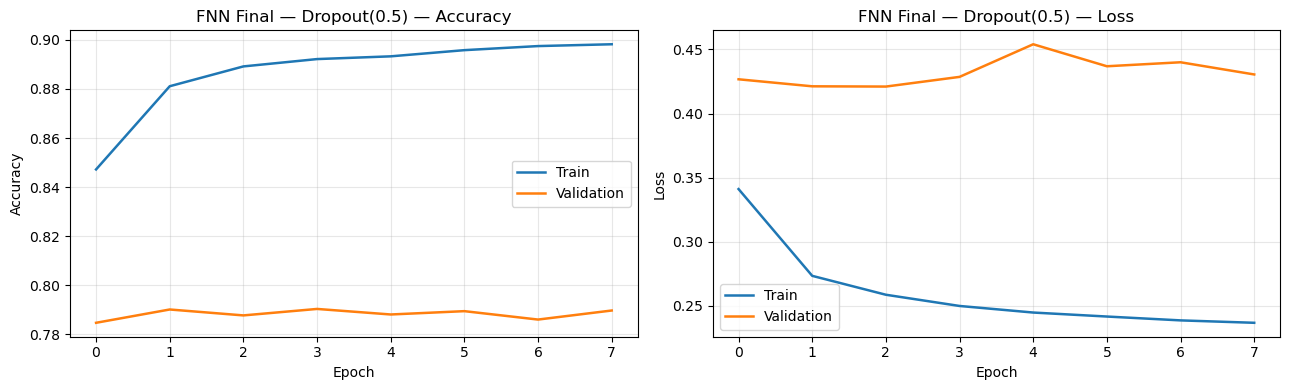

In [9]:
fnn_final = build_fnn_final(INPUT_DIM, dropout=0.5)
fnn_final.summary()

history_fnn_final = train_model(
    fnn_final, X_train_p, y_train, X_val_p, y_val,
    epochs=20, batch_size=32, patience=5
)
fnn_final_results = evaluate_model(
    fnn_final, X_train_p, y_train, X_val_p, y_val, X_test_p, y_test
)
plot_history(history_fnn_final, "FNN Final — Dropout(0.5)")

A introdução de Dropout reduziu a accuracy no treino face às arquiteturas FNN mais profundas sem regularização, mas melhorou a capacidade de generalização, permitindo atingir cerca de 79% em validação e teste. Este comportamento confirma que a regularização ajudou a controlar o overfitting e a produzir um modelo mais equilibrado e robusto.
Este resultado torna o FNN Final uma referência forte para a comparação posterior com a CNN Final.

## 7. CNN Baseline

Para aplicar Conv1D a dados tabulares, a entrada é reformulada de (n, features) para (n, features, 1), permitindo tratar cada observação como uma sequência unidimensional para efeitos de convolução. A arquitetura baseline adotada é Conv1D(32) → MaxPooling1D → Flatten → Dense(1, sigmoid).


Model: "cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 453, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 226, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7232)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │         7,233 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,361 (28.75 KB)

 Trainable params: 7,361 (28.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.8384 - loss: 0.3474 - val_accuracy: 0.7638 - val_loss: 0.4680
Epoch 2/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.8596 - loss: 0.3098 - val_accuracy: 0.7643 - val_loss: 0.4661
Epoch 3/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.8653 - loss: 0.3027 - val_accuracy: 0.7669 - val_loss: 0.4628
Epoch 4/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.8669 - loss: 0.2980 - val_accuracy: 0.7651 - val_loss: 0.4655
Epoch 5/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8679 - loss: 0.2945 - val_accuracy: 0.7667 - val_loss: 0.4604
Epoch 6/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.8705 - loss: 0.2922 - val_accuracy: 0.7644 - val_loss: 0.4697
Epoch 7/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8717 - loss: 0.2898 - val_accuracy: 0.7668 - val_loss: 0.4619
Epoch 8/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.8713 - loss: 0

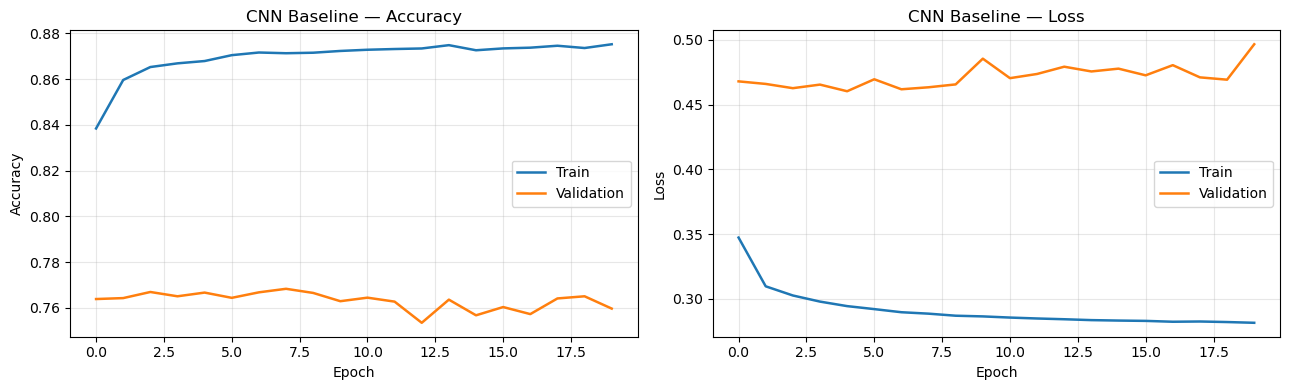

In [10]:
cnn_baseline = build_cnn_baseline(INPUT_DIM_CNN)
cnn_baseline.summary()

history_cnn_baseline = train_model_no_early_stop(
    cnn_baseline, X_train_cnn, y_train, X_val_cnn, y_val, epochs=20, batch_size=32
)
cnn_baseline_results = evaluate_model(
    cnn_baseline, X_train_cnn, y_train, X_val_cnn, y_val, X_test_cnn, y_test
)
plot_history(history_cnn_baseline, "CNN Baseline")


O baseline CNN atinge ~87% no treino e ~76–77% em validação e teste — desempenho competitivo face ao FNN baseline.  
Isto sugere que convolution layers conseguem captar padrões relevantes mesmo em dados tabulares, justificando a exploração de arquitecturas mais complexas.


## 8. CNN Final

Adota-se uma arquitetura CNN mais profunda com regularização: Conv1D(32) → Conv1D(64) → MaxPooling1D → Flatten → Dense(32) → Dropout(0.5) → Dense(1), treinada com EarlyStopping(patience=5). O objetivo é reduzir o overfitting observado nas versões convolucionais anteriores e melhorar a capacidade de generalização, enquanto o EarlyStopping preserva os pesos da melhor época.


Model: "cnn_final"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 453, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 451, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 225, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │       460,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 467,201 (1.78 MB)

 Trainable params: 467,201 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - accuracy: 0.8383 - loss: 0.3551 - val_accuracy: 0.7763 - val_loss: 0.4295
Epoch 2/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - accuracy: 0.8606 - loss: 0.3165 - val_accuracy: 0.7721 - val_loss: 0.4244
Epoch 3/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.8669 - loss: 0.3039 - val_accuracy: 0.7710 - val_loss: 0.4307
Epoch 4/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.8700 - loss: 0.2961 - val_accuracy: 0.7794 - val_loss: 0.4235
Epoch 5/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8730 - loss: 0.2888 - val_accuracy: 0.7827 - val_loss: 0.4391
Epoch 6/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8749 - loss: 0.2859 - val_accuracy: 0.7753 - val_loss: 0.4425
Epoch 7/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8751 - loss: 0.2856 - val_accuracy: 0.7907 - val_loss: 0.4159
Epoch 8/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.8775 - loss

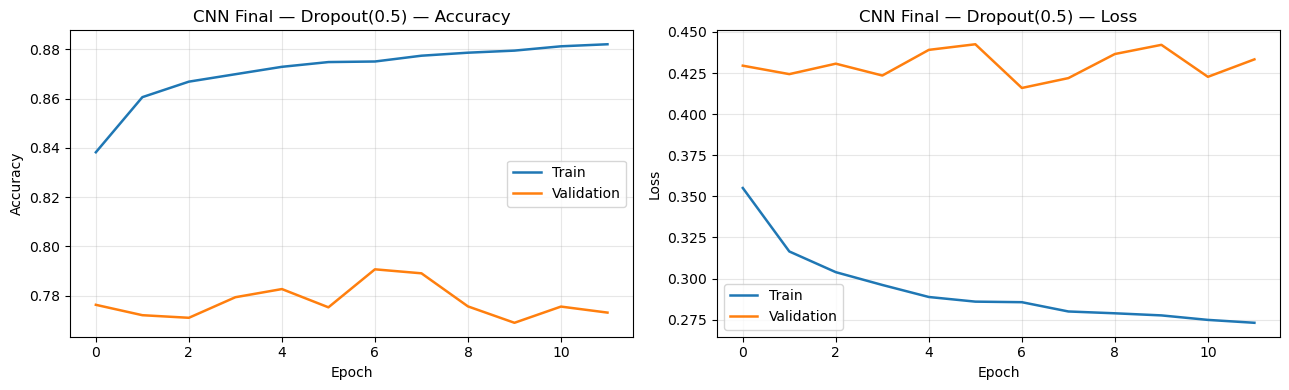

In [11]:
cnn_final = build_cnn_final(INPUT_DIM_CNN, dropout=0.5)
cnn_final.summary()

history_cnn_final = train_model(
    cnn_final, X_train_cnn, y_train, X_val_cnn, y_val,
    epochs=20, batch_size=32, patience=5
)
cnn_final_results = evaluate_model(
    cnn_final, X_train_cnn, y_train, X_val_cnn, y_val, X_test_cnn, y_test
)
plot_history(history_cnn_final, "CNN Final — Dropout(0.5)")


A CNN final atinge cerca de 79% em validação e 78% em teste, mostrando melhoria face ao baseline CNN. Apesar de alguma oscilação na val_loss, a regularização com Dropout e o EarlyStopping contribuíram para uma generalização mais estável do que a observada no baseline.

Foram testadas outras variações intermédias de FNN e CNN durante a fase experimental. Nesta versão final apresentam-se apenas os modelos mais relevantes para o workflow metodológico e para a comparação final.

## 9. Comparação Final

In [15]:
results = {
    "FNN Baseline":  fnn_baseline_results,
    "FNN Final ★":     fnn_final_results,
    "CNN Baseline":  cnn_baseline_results,
    "CNN Final":   cnn_final_results,
    }
display(compare_models(results))


c:\Projetos\hotel_cancellation_deeplearning\src\evaluate.py:99: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: f"{x:.4f}")


,Train Acc,Val Acc,Test Acc
FNN Baseline,0.8574,0.7757,0.7719
FNN Final ★,0.9002,0.7877,0.7852
CNN Baseline,0.8700,0.7597,0.7739
CNN Final,0.8958,0.7907,0.7772



=== Classification Report — CNN Final ===
                  precision    recall  f1-score   support

Not Canceled (0)       0.84      0.83      0.84     18163
    Canceled (1)       0.65      0.66      0.65      8402

        accuracy                           0.78     26565
       macro avg       0.74      0.74      0.74     26565
    weighted avg       0.78      0.78      0.78     26565



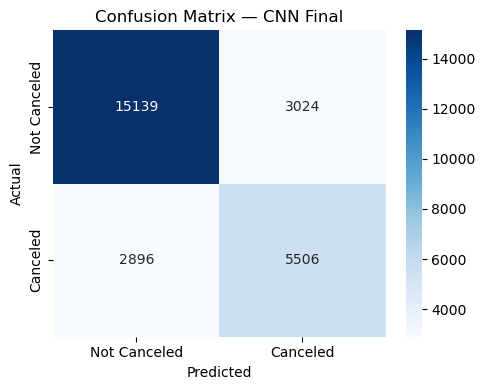


=== Classification Report — FNN Final ===
                  precision    recall  f1-score   support

Not Canceled (0)       0.82      0.89      0.85     18163
    Canceled (1)       0.70      0.57      0.62      8402

        accuracy                           0.79     26565
       macro avg       0.76      0.73      0.74     26565
    weighted avg       0.78      0.79      0.78     26565



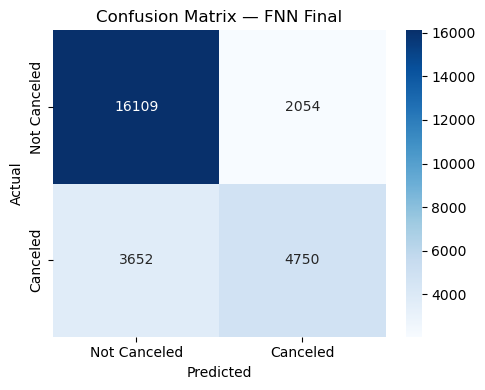

In [13]:
plot_confusion_matrix(cnn_final, X_test_cnn, y_test, title="CNN Final")
plot_confusion_matrix(fnn_final, X_test_p,   y_test, title="FNN Final")


**Leitura dos resultados:**

- Ambos os modelos finais atingem cerca de `79%` de `accuracy`, com desempenho global muito próximo.
- A `CNN Final` apresenta `F1-score` ligeiramente superior na classe `Canceled (1)`, refletindo melhor equilíbrio entre `precision` e `recall` na deteção de cancelamentos.
- A `FNN Final` obtém `test accuracy` ligeiramente superior (`78.52%` vs `77.72%`), com uma diferença de `0.8 p.p.` face à `CNN Final`.
- Num contexto hoteleiro, os `false negatives` — cancelamentos não detetados — podem ser particularmente relevantes; nesse critério, a `CNN Final` apresenta vantagem.


## 10. Conclusão e Utilidade do Modelo

O melhor desempenho global foi obtido pelo modelo `FNN Final`, que apresentou melhor capacidade de generalização no conjunto de teste. A `CNN Final` revelou desempenho competitivo, mas não superior, o que é coerente com a natureza tabular dos dados utilizados.

Embora o `FNN Final` tenha apresentado o melhor desempenho global, a `CNN Final` revelou vantagem na deteção da classe `Canceled (1)`, o que pode ser especialmente relevante em contextos onde seja prioritário reduzir `false negatives`.

Do ponto de vista prático, o modelo pode ser útil para `identificar reservas com maior probabilidade de cancelamento no momento da reserva`, apoiando decisões operacionais e comerciais, como gestão de ocupação, contacto preventivo com clientes e ajustamento de políticas de reserva. Esta utilidade está alinhada com o objetivo do projeto de antecipar comportamentos de risco e apoiar decisões mais informadas.

Como limitações, destaca-se a natureza tabular do dataset, a `ausência de identificador único de reserva` e a necessidade de testar mais variações de tuning e métricas de decisão. Como trabalho futuro, poderão ser exploradas novas features, ajuste de limiares de classificação e comparação com outros modelos de `machine learning`.


In [14]:
# Exemplo de previsão — reserva com perfil de risco elevado
new_booking = pd.DataFrame([{
    "hotel": "City Hotel", "lead_time": 300,
    "arrival_date_year": 2017, "arrival_date_month": "August",
    "arrival_date_week_number": 35, "arrival_date_day_of_month": 25,
    "stays_in_weekend_nights": 1, "stays_in_week_nights": 3,
    "adults": 2, "children": 0, "babies": 0, "meal": "BB",
    "country": "PRT", "market_segment": "Online TA",
    "distribution_channel": "TA/TO", "is_repeated_guest": 0,
    "previous_cancellations": 5, "previous_bookings_not_canceled": 0,
    "reserved_room_type": "A", "deposit_type": "Non Refund",
    "agent": "9.0", "customer_type": "Transient",
    "adr": 180.0, "required_car_parking_spaces": 0,
    "total_of_special_requests": 0
}])

for col in CATEGORICAL_COLS:
    new_booking[col] = new_booking[col].astype(str)

new_p = preprocessor.transform(new_booking).toarray()

# Previsão com CNN Final
pred_cnn = cnn_final.predict(reshape_for_cnn(new_p), verbose=0)[0][0]
pred_fnn = fnn_final.predict(new_p, verbose=0)[0][0]

print(f"CNN Final — P(cancelamento): {pred_cnn:.4f} → {'Cancelado' if pred_cnn >= 0.5 else 'Não cancelado'}")
print(f"FNN Final — P(cancelamento): {pred_fnn:.4f} → {'Cancelado' if pred_fnn >= 0.5 else 'Não cancelado'}")


CNN Final — P(cancelamento): 1.0000 → Cancelado
FNN Final — P(cancelamento): 1.0000 → Cancelado
